# Importing Libraries

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

# Test set Image Processing

In [5]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 35144 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Tw

# Loading Model

In [6]:
cnn = tf.keras.models.load_model('plant_disease_model.keras')

#Visualising and Performing Prediction on Single image

In [8]:
import sys
!{sys.executable} -m pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
    --------------------------------------- 1.0/44.0 MB 6.2 MB/s eta 0:00:07
   - -------------------------------------- 1.6/44.0 MB 4.9 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/44.0 MB 4.4 MB/s eta 0:00:10
   --- ------------------------------------ 3.4/44.0 MB 4.2 MB/s eta 0:00:10
   --- ------------------------------------ 4.2/44.0 MB 4.2 MB/s eta 0:00:10
   ---- ----------------------------------- 5.0/44.0 MB 4.0 MB/s eta 0:00:10
   ----- ---------------------------------- 5.8/44.0 MB 4.0 MB/s eta 0:00:10
   ----- ---------------------------------- 6.6/44.0 MB 4.1 MB/s eta 0:00:10
   ------ --------------------------------- 7.1/44.0 MB 3.9 MB/s eta 0:00:10
   ------- -------------------------------- 8.1/44.0 MB 4.0 MB/s eta 0:00:10
   -------- ------------------------------- 8.9/44.0 MB 4.0 MB/s eta 0:00:09
   --


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import cv2

image_path = 'test/test/AppleCedarRust1.JPG'

img = cv2.imread(image_path)

## Testing Model

In [24]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

image_path = "test/AppleCedarRust1.JPG"

img = tf.keras.preprocessing.image.load_img(
    image_path,
    target_size=(128, 128)
)

input_arr = tf.keras.preprocessing.image.img_to_array(img)
input_arr = np.expand_dims(input_arr, axis=0)

predictions = cnn.predict(input_arr)

result_index = np.argmax(predictions)

print("Predicted class:", class_name[result_index])
print("Confidence:", np.max(predictions) * 100, "%")

FileNotFoundError: [Errno 2] No such file or directory: 'test/AppleCedarRust1.JPG'

In [21]:
print(predictions)

[[1.6943638e-09 1.0446785e-19 3.3485278e-01 1.1240490e-09 1.3980380e-04
  6.7867359e-07 1.4906815e-15 1.2718994e-15 5.1295829e-21 1.5673630e-19
  1.9770914e-17 8.7851850e-09 3.1396424e-10 5.3467124e-07 4.2577093e-07
  4.8979900e-09 6.6205139e-08 1.7501590e-10 1.8914867e-09 6.6495949e-01
  9.1846631e-16 7.0504816e-13 8.0824129e-06 3.6310121e-05 4.0038230e-11
  1.1687074e-10 1.5884937e-11 4.7915671e-10 4.4222782e-07 1.2320194e-08
  2.8213563e-07 1.2612303e-17 1.2978449e-10 1.9262492e-20 5.3379337e-09
  6.3094130e-09 1.1449172e-06 6.1370078e-15]]


In [22]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

19


TypeError: Image data of dtype object cannot be converted to float

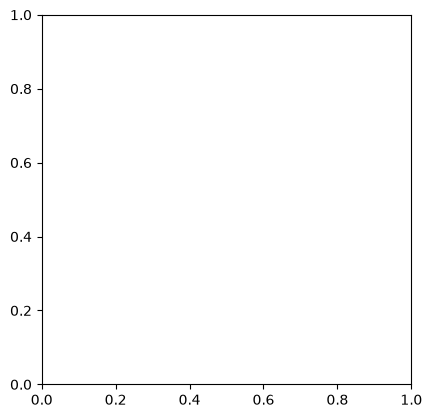

In [23]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()